**Parallel Workflow using LLMs with a reducer**

In [1]:
import operator
from typing import Annotated, List, TypedDict
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv


In [2]:
load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.1,
    max_retries=2,
)

In [3]:
# Define the structure of an individual evaluation
class Evaluation(BaseModel):
    aspect: str = Field(description="The aspect being evaluated (COT, DOA, or Language)")
    score: int = Field(description="Score from 0 to 10", ge=0, le=10)
    feedback: str = Field(description="Specific feedback for this aspect")

# Define the State with a Reducer
class EssayState(TypedDict):
    essay: str
    # The 'operator.add' ensures parallel results are appended to the list, not overwritten
    evaluations: Annotated[List[Evaluation], operator.add]
    final_summary: str
    average_score: float

In [4]:
# Bind the structured output tool
structured_llm = llm.with_structured_output(Evaluation)

In [12]:
def evaluate_cot(state: EssayState):
    """Evaluate Chain of Thought (Reasoning)"""
    prompt = f"Evaluate the logical reasoning and 'Chain of Thought' in this essay:\n\n{state['essay']}"
    # We set the aspect manually so the final_eval knows which is which
    result = structured_llm.invoke(prompt)
    result.aspect = "COT"
    print(f"--- [DEBUG] COT Node Finished ---")
    print(f"Score: {result.score} | Feedback: {result.feedback[:50]}...")

    return {"evaluations": [result]}

def evaluate_doa(state: EssayState):
    """Evaluate Depth of Analysis"""
    prompt = f"Evaluate the 'Depth of Analysis' (DOA) and evidence provided in this essay:\n\n{state['essay']}"
    result = structured_llm.invoke(prompt)
    result.aspect = "DOA"

    print(f"--- [DEBUG] DOA Node Finished ---")
    print(f"Score: {result.score} | Feedback: {result.feedback[:50]}...")

    return {"evaluations": [result]}

def evaluate_language(state: EssayState):
    """Evaluate Language and Grammar"""
    prompt = f"Evaluate the language, grammar, and vocabulary usage in this essay:\n\n{state['essay']}"
    result = structured_llm.invoke(prompt)
    result.aspect = "Language"

    print(f"--- [DEBUG] LANGUAGE Node Finished ---")
    print(f"Score: {result.score} | Feedback: {result.feedback[:50]}...")

    return {"evaluations": [result]}

In [13]:
def final_eval(state: EssayState):
    evals = state['evaluations']
    avg_score = sum(e.score for e in evals) / len(evals)
    
    summary_prompt = f"Summarize the following feedback into a final verdict:\n{evals}"
    summary = llm.invoke(summary_prompt).content
    
    return {
        "final_summary": summary,
        "average_score": avg_score
    }

In [7]:
builder = StateGraph(EssayState)

builder.add_node("evaluate_cot", evaluate_cot)
builder.add_node("evaluate_doa", evaluate_doa)
builder.add_node("evaluate_language", evaluate_language)
builder.add_node("final_eval", final_eval)

# Parallel Fan-out
builder.add_edge(START, "evaluate_cot")
builder.add_edge(START, "evaluate_doa")
builder.add_edge(START, "evaluate_language")

# Fan-in (Join)
builder.add_edge("evaluate_cot", "final_eval")
builder.add_edge("evaluate_doa", "final_eval")
builder.add_edge("evaluate_language", "final_eval")

builder.add_edge("final_eval", END)

workflow = builder.compile()

In [ ]:
initial_input = {"essay": '''In our modern, high-speed world, laziness is considered a sin, and busyness is worn as a badge of honor. We measure our worth by our productivity—how many emails we answered, how many tasks we completed, how many places we visited. Yet, in this relentless pursuit of "more," we have lost the profound value of doing absolutely nothing.''', "evaluations": []}

for chunk in workflow.stream(initial_input):
    for node_name, output in chunk.items():
        print(f"\nNode '{node_name}' just finished!")
        print(f"Output: {output}")
        print("-" * 20)


Node 'evaluate_doa' just finished!
Output: {'evaluations': [Evaluation(aspect='DOA', score=8, feedback='The essay provides a good analysis of the societal pressure to be constantly productive, but could delve deeper into the psychological and philosophical implications of valuing busyness over rest.')]}
--------------------

Node 'evaluate_cot' just finished!
Output: {'evaluations': [Evaluation(aspect='COT', score=8, feedback='The essay effectively challenges the conventional notion of busyness and productivity, highlighting the importance of taking time to do nothing. The author presents a clear and logical argument, starting with the current societal values and then contrasting them with the benefits of inactivity.')]}
--------------------

Node 'evaluate_language' just finished!
Output: {'evaluations': [Evaluation(aspect='Language', score=9, feedback='The language used is formal, sophisticated, and engaging, with a clear and concise tone.')]}
--------------------

Node 'final_eval'

In [10]:
essay_text = '''In our modern, high-speed world, laziness is considered a sin, and busyness is worn as a badge of honor. We measure our worth by our productivity—how many emails we answered, how many tasks we completed, how many places we visited. Yet, in this relentless pursuit of "more," we have lost the profound value of doing absolutely nothing.'''
result = workflow.invoke({"essay": essay_text, "evaluations": []})

print(f"Average Score: {result['average_score']}")
print(f"Summary: {result['final_summary']}")
for e in result['evaluations']:
    print(f"[{e.aspect}] Score: {e.score} | Feedback: {e.feedback}")

Average Score: 8.333333333333334
Summary: **Final Verdict:** 
The essay demonstrates a clear and well-structured chain of thought, effectively challenging a common societal norm. It provides a good analysis of the topic, although it could be improved with a more in-depth exploration of the consequences and potential benefits. The language used is formal, sophisticated, and clear, making the essay well-presented. Overall, the essay scores well, with an average score of 8.3 out of 10, indicating a strong performance in critical thinking and language use, with some room for improvement in depth of analysis.
[COT] Score: 8 | Feedback: The essay starts by presenting a common societal norm, then challenges it by introducing an opposing idea, showing a clear chain of thought in questioning the value of constant busyness.
[DOA] Score: 8 | Feedback: The essay provides a good analysis of the societal pressure to be constantly productive and the devaluation of rest, but it could benefit from more

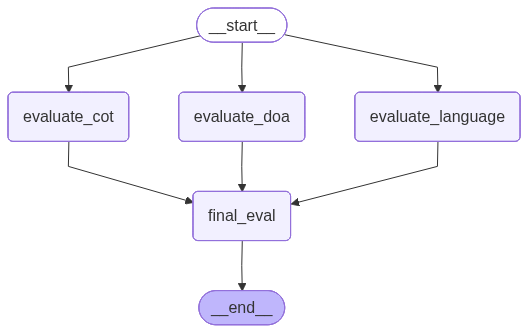

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())